Código adaptado de:

[1] A. Géron, Hands-On Machine Learning with Scikit-Learning, Keras & Tensorflow, Third Edition, O'Reilly, 2022.

# Importações

In [4]:
! pip install torchinfo

In [1]:
from __future__ import annotations                     # permite anotações de tipo
from typing import Dict, Tuple, Union                  # tipos usados em docstrings e type hints
import numpy as np                                     # operações numéricas e manipulação de arrays
from tqdm.auto import tqdm                             # barra de progresso para loops
from matplotlib import pyplot as plt                   # plotagem de gráficos e figuras
import torch                                           # tensores e computação em GPU
import torch.nn as nn                                  # módulos de redes neurais
import torch.optim as optim                            # otimizadores (Adam, SGD, NAdam, etc.)
from torch.utils.data import TensorDataset, DataLoader # manipulação de datasets e carregadores
from torchinfo import summary                          # exibe resumo detalhado da arquitetura da rede
from sklearn import datasets                           # conjuntos de dados
from sklearn.preprocessing import StandardScaler       # normalização de features

# Hiperparâmetros

In [117]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # usa GPU se disponível, caso contrário CPU
BATCH_SIZE = 256                                                       # tamanho do batch para treino
MODE = "cosine"                                                        # modo do scheduler de ruído ("linear", "quad", "cosine", etc.)
DATASET = "swiss_roll"                                                       # tipo de dataset 2D (ex.: "circle", "scurve", "moon", "swiss_roll")
NUM_EPOCHS = 50                                                        # número total de épocas de treinamento
BATCH_SIZE_SAMPLING = 1024                                             # tamanho do batch usado na amostragem (geração)
EMBEDDING_SIZE = 16                                                   # tamanho do embedding temporal (número de dimensões do encoding senoidal)
NUM_STEPS = 1000                                                     # número total de passos de difusão T

# Dados

In [3]:
def load_datasets_2d(num_samples: int, dataset: str):

    match dataset:
        case "normal":
            sample = np.random.normal(size=(num_samples, 2))

        case "circle":
            X, _ = datasets.make_circles(n_samples=num_samples, noise=0.0, random_state=None, factor=0.5)
            sample = X

        case "scurve":
            X, _ = datasets.make_s_curve(n_samples=num_samples, noise=0.0, random_state=None)
            sample = X[:, [0, 2]]

        case "moon":
            X, _ = datasets.make_moons(n_samples=num_samples, noise=0.0, random_state=None)
            sample = X

        case "swiss_roll":
            X, _ = datasets.make_swiss_roll(n_samples=num_samples, noise=0.0, random_state=None, hole=True)
            sample = X[:, [0, 2]]

        case _:
            raise ValueError(f"Unknown dataset: {dataset}")

    scaler = StandardScaler()
    sample = scaler.fit_transform(sample)

    return torch.tensor(sample, dtype=torch.float32)

In [4]:
# Geração dos dados
N = 100_000
X   = load_datasets_2d(num_samples=N, dataset=DATASET)
Z_T = load_datasets_2d(num_samples=N, dataset="normal")  # prior

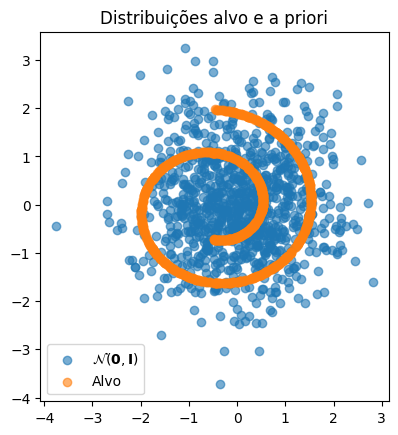

In [5]:
# Visualização
num_samples_plot = 1000
sample_forward = X[0:num_samples_plot]
sample_backward = Z_T[0:num_samples_plot]

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(sample_backward[:, 0], sample_backward[:, 1], alpha=0.6)
ax.scatter(sample_forward[:, 0], sample_forward[:, 1], alpha=0.6)
ax.grid(False)
ax.set_aspect('equal', adjustable='box')
ax.set_title("Distribuições alvo e a priori")
_ = ax.legend([r'$\mathcal{N}(\mathbf{0}, \mathbf{I})$', r'Alvo'])

In [6]:
train_ds = TensorDataset(X)                                             # dataset
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)    # dataloader

In [7]:
# Verificando o primeiro batch
xb, = next(iter(train_dl))
print(xb.shape)

torch.Size([256, 2])


# Cronograma (da variância) do ruído $\{ \beta_t \}_{t=1}^T$

Lembrete: função cosseno

In [8]:
T = NUM_STEPS
t = np.arange(T + 1)            # t = [0, 1, ..., T]
f = np.cos((t / T) * np.pi / 2) # cos(0)=1 a cos(pi/2)=0

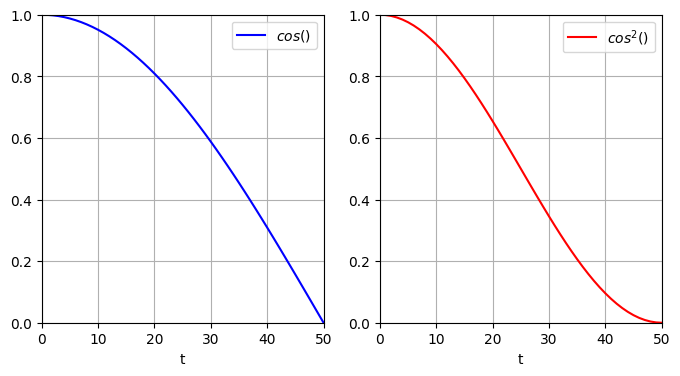

In [9]:
plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
plt.plot(t, f, "b", label=r"$cos()$")
plt.axis([0, T, 0, 1])
plt.grid(True)
plt.xlabel(r"t")
plt.legend()

plt.subplot(1,2,2)
plt.plot(t, f**2, "r", label=r"$cos^2()$")
plt.axis([0, T, 0, 1])
plt.grid(True)
plt.xlabel(r"t")
plt.legend()

plt.show()

**Kernel de difusão**: $\quad \mathbf z_t = \underbrace{\sqrt{\bar{\alpha}_t}}_{\substack{\text{fator de escala}\\\text{do sinal}}}
\cdot
\underbrace{\mathbf x}_{\substack{\text{sinal}\\\text{(ex.: imagem)}}} + \underbrace{\sqrt{1-\bar{\alpha}_t}}_{\substack{\text{fator de escala}\\\text{do ruído}}}  
\cdot
\underbrace{\mathbf \epsilon}_{\text{ruído}}$

$q(\mathbf z_t | \mathbf x) = \mathcal N \left( \sqrt{\bar{\alpha}_t}x, (1-\bar{\alpha}_t) \mathbf I \right)$

- Onde:
  - $\alpha_0 = 1$
  - $\alpha_t = (1 - \beta_t)$
  - $\displaystyle  \bar{\alpha}_t= \prod_{s=1}^{t} \alpha_s$
  - $\mathbf \epsilon \sim \mathcal N(\mathbf 0, \mathbf I)$

**Cronograma de ruído**: $\displaystyle \quad \beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}$

$\quad \displaystyle  \bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s  = \alpha_t \cdot \underbrace{\prod_{s=1}^{t-1} \alpha_s}_{\bar{\alpha}_{t-1}} = \alpha_t \cdot \bar{\alpha}_{t-1} \implies \underbrace{\alpha_t}_{(1-\beta_t)} = \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}} \implies \boxed{\beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}}$

- Onde:
  - $\displaystyle \bar{\alpha}_t = \frac{f(t)}{f(0)}$
  - $\displaystyle f(t) = \cos^2 \left( \frac{t/T + s}{1+s} \cdot \frac{\pi}{2}\right) $
  - $s$: hiperparâmetro com valor pequeno (ex.: $s=0.008$) para evitar $\beta_t$ muito pequeno perto de $t=0$.
  - o valor de $\beta_t$ é limitado a $0.999$ para evitar instabilidades perto de $t=T$.


In [10]:
class NoiseScheduler(nn.Module):

    def __init__(
        self,
        T: int,
        mode: str = "linear",           # "linear" | "quad" | "cosine"
    ):
        super().__init__()

        self.T = int(T) # número total de passos de difusão
        self.mode = mode

        match mode:
            case "linear":
                betas, alphas, alphas_bar = self._make_linear()
            case "quad":
                betas, alphas, alphas_bar = self._make_quad()
            case "cosine":
                betas, alphas, alphas_bar = self._make_cosine()
            case _:
                raise NotImplementedError(f"{mode} is not implemented.")

        # register buffers
        self.register_buffer("betas", betas.to(torch.float32))
        self.register_buffer("alphas", alphas.to(torch.float32))
        self.register_buffer("alphas_bar", alphas_bar.to(torch.float32))

    def _make_linear(self, beta_1: float = 1e-4, beta_T: float = 2e-2):
        """
        β_t cresce linearmente de beta_1 até beta_T.
        α_t = 1 - β_t,   α̅_t = ∏_{i=0}^t α_i.
        """
        betas = torch.linspace(beta_1, beta_T, steps=self.T + 1, dtype=torch.float32)
        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)
        return betas, alphas, alphas_bar

    def _make_quad(self, beta_1: float = 1e-4, beta_T: float = 2e-2):
        """
        β_t cresce quadraticamente (como sqrt-linear).
        """
        betas = torch.linspace(beta_1**0.5, beta_T**0.5, steps=self.T + 1, dtype=torch.float32) ** 2
        alphas = 1.0 - betas
        alphas_bar = torch.cumprod(alphas, dim=0)
        return betas, alphas, alphas_bar

    # Programação cosseno
    def _make_cosine(self, s: float = 0.008, max_beta: float = 0.999):
        """
        f(t) = cos²(((t/T + s)/(1 + s)) * π/2),   t = 0..T.
        α̅_t = f(t)/f(0)
        α_t = α̅_t / α̅_{t-1} = f(t)/f(t-1)
        β_t = 1 - α_t
        """
        t = np.arange(self.T + 1)                                                               # cria vetor de tempos t = [0, 1, ..., T]
        f = np.cos((t / self.T + s) / (1 + s) * np.pi / 2) ** 2                                 # aplica a programação cosseno ao quadrado (cos²) sugerida no artigo do "Improved DDPM"
        alphas = np.clip(f[1:] / f[:-1], 1 - max_beta, 1)                                       # alpha = [α_1, ..., α_T]. Calcula α_t = f_t / f_{t-1} (formulação recursiva), limitando valores para evitar β_t > max_beta.
        alphas = np.append(1.0, alphas)                                                         # alpha = [α_0 = 1, α_1, ..., α_T]. Adiciona α₀ = 1 no início do vetor
        betas = 1 - alphas                                                                      # β_t = 1 - α_t
        alphas_bar = np.cumprod(alphas)                                                         # calcula produto cumulativo α̅_t = ∏_{i=0}^t α_i
        return torch.from_numpy(betas), torch.from_numpy(alphas), torch.from_numpy(alphas_bar)  # retorna β_t, α_t, e α̅_t para todos os passos t

In [11]:
noise_scheduler = NoiseScheduler(T=NUM_STEPS, mode=MODE)   # inicializa o cronograma de ruído (define β_t, α_t, e α̅_t para T passos)

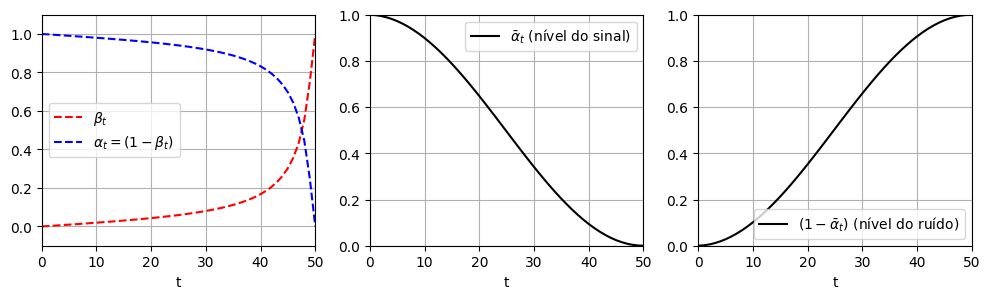

In [12]:
plt.figure(figsize=(12, 3))                                            # cria figura com 3 subplots lado a lado

# β_t e α_t
plt.subplot(1,3,1)                                                     # primeiro subplot: betas e alphas
plt.plot(noise_scheduler.betas.cpu().numpy(), "r--", label=r"$\beta_t$")               # curva de betas (ruído adicionado)
plt.plot(noise_scheduler.alphas.cpu().numpy(), "b--", label=r"$\alpha_t = (1 - \beta_t)$")  # curva de alphas (sinal preservado)
plt.axis([0, T, -0.1, 1.1])                                            # define limites dos eixos
plt.grid(True)                                                         # ativa grade
plt.xlabel(r"t")                                                       # rótulo eixo x (tempo)
plt.legend()                                                           # exibe legenda

# α̅_t
plt.subplot(1,3,2)                                                     # segundo subplot: alpha_bar (nível do sinal)
plt.plot(noise_scheduler.alphas_bar.cpu().numpy(), "k", label=r"$\bar{\alpha}_t$ (nível do sinal)")
plt.axis([0, T, 0, 1])                                                 # define limites do gráfico
plt.grid(True)                                                         # ativa grade
plt.xlabel(r"t")                                                       # rótulo eixo x (tempo)
plt.legend()                                                           # exibe legenda

# 1 - α̅_t
plt.subplot(1,3,3)                                                     # terceiro subplot: 1 - alpha_bar (nível do ruído)
plt.plot(1 - noise_scheduler.alphas_bar.cpu().numpy(), "k", label=r"$(1 - \bar{\alpha}_t)$ (nível do ruído)")
plt.axis([0, T, 0, 1])                                                 # define limites do gráfico
plt.grid(True)                                                         # ativa grade
plt.xlabel(r"t")                                                       # rótulo eixo x (tempo)
plt.legend()                                                           # exibe legenda

plt.show()                                                             # mostra todos os gráficos

Variáveis:
*   `alpha`: $[\alpha_0, \alpha_1, \ldots, \alpha_T]$.
*   `alpha_bar`: $[\bar{\alpha}_0, \bar{\alpha}_1, \ldots, \bar{\alpha}_T]$.
*   `beta`: $[\beta_0, \beta_1, \ldots, \beta_T]$.

In [13]:
print(f'betas: {noise_scheduler.betas}\n')              # imprime os valores de β_t (taxas de ruído adicionadas a cada passo)
print(f'alphas: {noise_scheduler.alphas}\n')            # imprime os valores de α_t = 1 - β_t (fração de sinal preservada por passo)
print(f'alphas_bar: {noise_scheduler.alphas_bar}\n')    # imprime os valores acumulados α̅_t = ∏_{i=1}^t α_i (decadência total do sinal até t)

betas: tensor([0.0000, 0.0017, 0.0037, 0.0056, 0.0076, 0.0095, 0.0115, 0.0135, 0.0155,
        0.0176, 0.0197, 0.0218, 0.0240, 0.0262, 0.0284, 0.0307, 0.0331, 0.0356,
        0.0382, 0.0408, 0.0435, 0.0464, 0.0494, 0.0526, 0.0559, 0.0594, 0.0630,
        0.0670, 0.0712, 0.0757, 0.0805, 0.0857, 0.0914, 0.0977, 0.1045, 0.1121,
        0.1206, 0.1301, 0.1409, 0.1534, 0.1679, 0.1850, 0.2055, 0.2306, 0.2622,
        0.3031, 0.3581, 0.4362, 0.5548, 0.7498, 0.9990])

alphas: tensor([1.0000, 0.9983, 0.9963, 0.9944, 0.9924, 0.9905, 0.9885, 0.9865, 0.9845,
        0.9824, 0.9803, 0.9782, 0.9760, 0.9738, 0.9716, 0.9693, 0.9669, 0.9644,
        0.9618, 0.9592, 0.9565, 0.9536, 0.9506, 0.9474, 0.9441, 0.9406, 0.9370,
        0.9330, 0.9288, 0.9243, 0.9195, 0.9143, 0.9086, 0.9024, 0.8955, 0.8879,
        0.8794, 0.8699, 0.8591, 0.8466, 0.8321, 0.8150, 0.7945, 0.7694, 0.7378,
        0.6969, 0.6419, 0.5638, 0.4452, 0.2502, 0.0010])

alphas_bar: tensor([1.0000e+00, 9.9825e-01, 9.9457e-01, 9.8897e-01, 9

# Embeddings de tempo

- Positional (Temporal) Encoding: $\displaystyle \quad \mathbf{e}(t) =
\bigl[
\underbrace{\sin(\omega_0 t)}_{e_0(t)},\,
\underbrace{\cos(\omega_0 t)}_{e_1(t)},\,
\underbrace{\sin(\omega_1 t)}_{e_2(t)},\,
\underbrace{\cos(\omega_1 t)}_{e_3(t)},\,
\dots,\,
\underbrace{\sin(\omega_{\frac{D}{2} - 1} t)}_{e_{D-2}(t)},\,
\underbrace{\cos(\omega_{\frac{D}{2}  - 1} t)}_{e_{D-1}(t)}
\bigr]_{1 \times D}, \quad
t \in \{0,1,\dots,T\}.$

    - onde: $\displaystyle \quad  \omega_i = \frac{1}{L^{2i / D}}, \quad i = 0, 1, \dots, \frac{D}{2}-1$, $\quad D$ é o comprimento desejado do embedding temporal.

- $\mathbf{e}(t)$ é um vetor com pares (seno, cosseno) de frequências progressivamente menores:

$
\Rightarrow \quad
\begin{aligned}
\text{Para as dimensões pares:}  &\quad e_{2i}(t)   = \sin \left( \frac{t}{L^{2i/D}} \right), \\[0.5em]
\text{Para as dimensões ímpares:}&\quad e_{2i+1}(t) = \cos \left( \frac{t}{L^{2i/D}} \right).
\end{aligned}
$

- Cada par $(2i,2i+1)$ usa a mesma frequência, e as frequências decaem conforme $i$ cresce.

- O embedding senoidal completo é:

$
\mathbf{E} =
\begin{bmatrix}
e_0(0) & e_1(0) & \dots & e_{D-1}(0) \\
e_0(1) & e_1(1) & \dots & e_{D-1}(1) \\
\vdots & \vdots & \ddots & \vdots \\
e_0(T) & e_1(T) & \dots & e_{D-1}(T)
\end{bmatrix}_{(T+1) \times D}
$

In [14]:
class TimeEncoding(nn.Module):
    """
    Implementa um embedding senoidal fixo para passos de tempo discretos t ∈ {0, 1, ..., T}.

    Cada passo t é mapeado em um vetor de dimensão `embed_size`, construído com
    funções senoidais e cossenoidais de frequências logaritmicamente espaçadas,
    conforme a fórmula usada em "Attention Is All You Need" (Vaswani et al., 2017).

    Parameters
    ----------
    T : int
        Número máximo de passos de tempo (inclusive).
    embed_size : int
        Tamanho do embedding (deve ser par para permitir pares sin/cos).

    Attributes
    ----------
    time_encodings : torch.Tensor
        Tabela precomputada de embeddings senoidais de forma (T+1, embed_size),
        registrada como buffer (não-treinável).

    Methods
    -------
    forward(t: torch.Tensor) -> torch.Tensor
        Retorna o embedding correspondente aos índices de tempo informados.
    """

    def __init__(self, T: int, embed_size: int, L: float = 100.0) -> None:
        """Inicializa e precomputa a tabela de embeddings senoidais."""
        super().__init__()                                              # inicializa a superclasse nn.Module
        assert embed_size % 2 == 0, "embed_size deve ser par"           # garante que embed_size é par (pares sin/cos)
        self.T = T                                                      # salva o número máximo de passos de tempo
        self.embed_size = embed_size                                    # salva o tamanho do embedding
        steps = np.arange(T + 1)                                        # vetor de tempos discretos: [0, 1, ..., T] - shape (T+1, )
        ind_freqs = 2 * np.arange(embed_size // 2)                      # índices pares: [0, 2, 4, ..., embed_size - 2] -> correspondem às frequências - shape (embed_size/2, )
        p, i = np.meshgrid(steps, ind_freqs)                            # cria malha (p: tempo - shape (D/2, T+1), i: frequência - shape (D/2, T+1))
        denom = (L ** (i / embed_size))                                 # fator de normalização: controla o decaimento das frequências - shape (D/2, T+1)
        t_emb = np.empty((T + 1, embed_size), dtype=np.float32)         # aloca matriz de embeddings - shape (T+1, D)
        t_emb[:, ::2] = np.sin(p / denom).T                             # preenche colunas pares com senos (array[início:fim:passo])
        t_emb[:, 1::2] = np.cos(p / denom).T                            # preenche colunas ímpares com cossenos (array[início:fim:passo])
        self.register_buffer("time_encodings", torch.from_numpy(t_emb)) # registra tensor como buffer (não-treinável)

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Retorna o embedding senoidal correspondente a cada índice de tempo.

        Parameters
        ----------
        t : torch.Tensor
            Tensor 1D de índices de tempo (valores inteiros em [0, T]).

        Returns
        -------
        torch.Tensor
            Tensor contendo os embeddings senoidais correspondentes a `t`,
            com formato (B, embed_size), onde B é o tamanho do batch.
        """
        t = t.clamp(min=0, max=self.T).long()   # garante que t está dentro de [0, T] e converte para inteiro
        return self.time_encodings[t]           # retorna os embeddings pré-computados correspondentes a t

In [15]:
# cria o codificador senoidal de tempo e move para o dispositivo (CPU/GPU)
time_enc = TimeEncoding(T=NUM_STEPS, embed_size=EMBEDDING_SIZE).to(DEVICE)

In [16]:
# define alguns passos de tempo de exemplo: início, meio e fim
time_steps = torch.tensor([0, EMBEDDING_SIZE // 2, EMBEDDING_SIZE], dtype=torch.int64)

# obtém os embeddings correspondentes e converte para NumPy
emb = time_enc(time_steps).cpu().numpy()

# exibe o formato do resultado (3, EMBEDDING_SIZE)
print(f'emb shape = {emb.shape}')

emb shape = (3, 32)


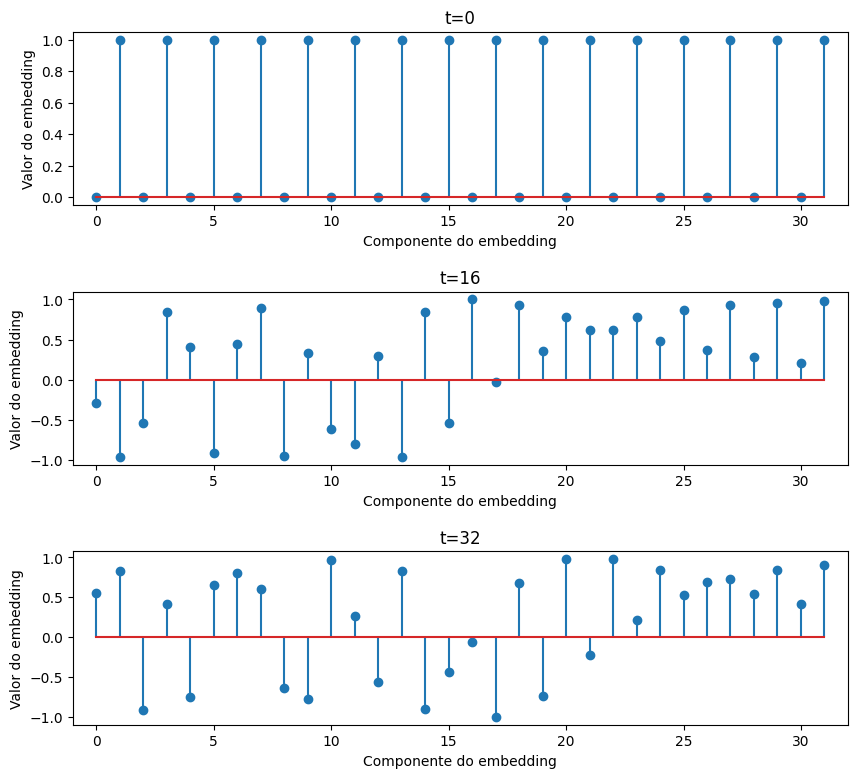

In [17]:
plt.figure(figsize=(10,9))                     # cria figura com tamanho 10x9 polegadas

plt.subplot(3,1,1)                             # primeiro subplot (linha 1 de 3)
plt.stem(emb[0])                               # plota o embedding do tempo t[0] em formato stem (linha vertical)
plt.title(fr"t={time_steps[0]}")               # título com o valor de t
plt.xlabel("Componente do embedding")          # rótulo do eixo x: índice da dimensão (0, 1, 2, ..., D−1)
plt.ylabel("Valor do embedding")               # rótulo do eixo y: valor numérico do embedding (entre -1 e 1)
plt.xlim(-1, EMBEDDING_SIZE)                   # limita eixo x ao intervalo [-1, EMBEDDING_SIZE]

plt.subplot(3,1,2)                             # segundo subplot (linha 2 de 3)
plt.stem(emb[1])                               # plota o embedding do tempo t[1]
plt.title(fr"t={time_steps[1]}")               # título com o valor de t
plt.xlabel("Componente do embedding")          # rótulo do eixo x: índice da dimensão (0, 1, 2, ..., D−1)
plt.ylabel("Valor do embedding")               # rótulo do eixo y: valor numérico do embedding (entre -1 e 1)
plt.xlim(-1, EMBEDDING_SIZE)                   # define limites do eixo x

plt.subplot(3,1,3)                             # terceiro subplot (linha 3 de 3)
plt.stem(emb[2])                               # plota o embedding do tempo t[2]
plt.title(fr"t={time_steps[2]}")               # título com o valor de t
plt.xlabel("Componente do embedding")          # rótulo do eixo x: índice da dimensão (0, 1, 2, ..., D−1)
plt.ylabel("Valor do embedding")               # rótulo do eixo y: valor numérico do embedding (entre -1 e 1)
plt.xlim(-1, EMBEDDING_SIZE)                   # define limites do eixo x

plt.subplots_adjust(hspace=0.5)                  # aumenta o espaço vertical entre os subplots

plt.show()                                     # exibe todos os subplots

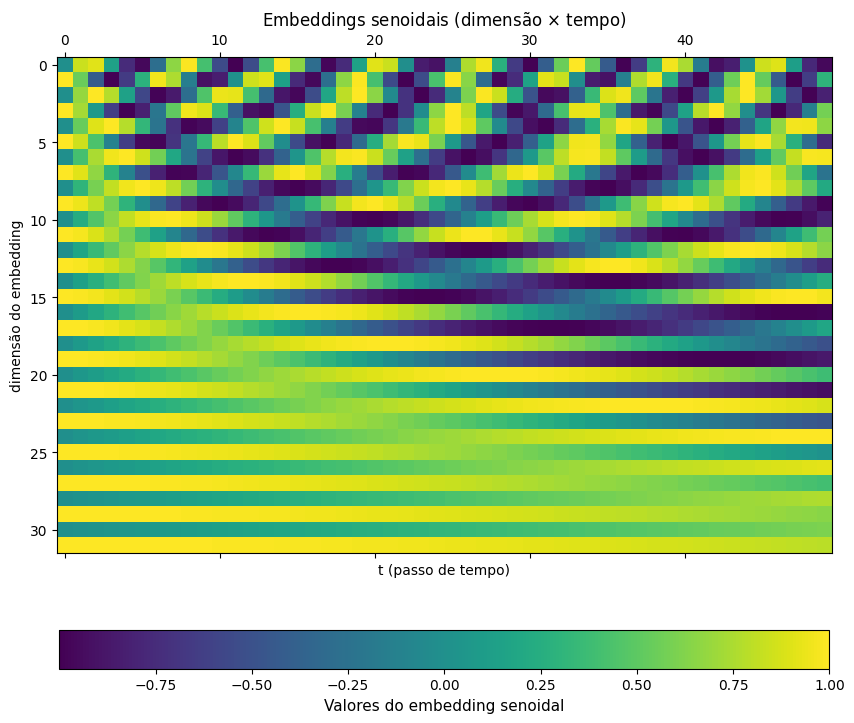

In [18]:
emb = time_enc(torch.arange(min(201, NUM_STEPS))).cpu().numpy()             # gera embeddings senoidais para até 201 passos (ou NUM_STEPS, se menor)
plt.figure(figsize=(10,10))                                                 # cria figura 10x10 polegadas
im = plt.matshow(emb.T, fignum=False)                                       # exibe matriz transposta (dimensão x tempo) como mapa de calor
cbar = plt.colorbar(im, orientation='horizontal', pad=0.1, fraction=0.05)   # adiciona barra de cores horizontal abaixo
cbar.set_label("Valores do embedding senoidal", fontsize=11)                # rotula a barra indicando o significado dos valores
plt.title(r"Embeddings senoidais (dimensão $\times$ tempo)")                # título do gráfico
plt.xlabel("t (passo de tempo)")                                            # rótulo do eixo x
plt.ylabel("dimensão do embedding")                                         # rótulo do eixo y
plt.show()                                                                  # exibe o gráfico completo

# Rede Neural

In [19]:
class NeuralNet(nn.Module):
    """
    Implementa uma rede neural simples para DDPM com dados 2D.

    A rede recebe um ponto ruidoso x_t ∈ ℝ² e o passo temporal t, codificado por um
    embedding senoidal (`time_encoder`). O embedding de tempo é processado por um
    pequeno MLP e concatenado ao vetor x_t antes de ser passado à MLP principal,
    que prediz o ruído ε̂ ∈ ℝ².

    Parameters
    ----------
    time_encoder : nn.Module
        Módulo de codificação temporal (`TimeEncoding`) que gera embeddings senoidais.
    hidden_layer_sizes : list[int], default=[32, 32, 32]
        Tamanhos das camadas ocultas da MLP principal.
    t_hidden : int, default=32
        Dimensão das features extraídas do embedding de tempo (saída da time_mlp).

    Attributes
    ----------
    time_mlp : nn.Sequential
        MLP responsável por processar o embedding de tempo e extrair suas features.
    main_mlp : nn.Sequential
        MLP principal que concatena x_t e as features de tempo e prediz o ruído ε̂.

    Methods
    -------
    forward(x: torch.Tensor, t: torch.Tensor) -> torch.Tensor
        Realiza a passagem direta (forward pass) e retorna a estimativa do ruído ε̂.
    """

    def __init__(self, time_encoder: nn.Module, hidden_layer_sizes: list[int] = [32, 32, 32], t_hidden: int = 32) -> None:
        """Inicializa a rede neural com MLP temporal e MLP principal."""

        super().__init__()                                             # inicializa superclasse nn.Module
        self.time_encoder = time_encoder                               # módulo que gera embeddings senoidais de tempo

        # MLP temporal: processa o embedding senoidal em features de dimensão t_hidden
        self.time_mlp = nn.Sequential(
            nn.Linear(self.time_encoder.embed_size, t_hidden, bias=True),
            nn.SiLU(),
            nn.Linear(t_hidden, t_hidden, bias=True)
        )

        # MLP principal: concatena x_t (2D) e as features temporais, e prediz o ruído ε̂ (2D)
        self.main_mlp = nn.Sequential(
            nn.Linear(2 + t_hidden, hidden_layer_sizes[0], bias=True),
            nn.SiLU(),
            nn.Linear(hidden_layer_sizes[0], hidden_layer_sizes[1], bias=True),
            nn.SiLU(),
            nn.Linear(hidden_layer_sizes[1], hidden_layer_sizes[2], bias=True),
            nn.SiLU(),
            nn.Linear(hidden_layer_sizes[2], 2, bias=True)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Realiza a passagem direta e retorna a estimativa do ruído ε̂ (x_t, t).

        Parameters
        ----------
        x : torch.Tensor
            Tensor contendo os pontos ruidosos x_t ∈ ℝ² — formato (B, 2),
            onde B é o tamanho do batch.
        t : torch.Tensor
            Tensor contendo os índices de tempo t ∈ [0, T] — formato (B,).

        Returns
        -------
        torch.Tensor
            Tensor com as estimativas de ruído ε̂ — formato (B, 2).
        """
        t_emb = self.time_encoder(t)            # (B, embed_size): obtém embedding senoidal de tempo
        t_feat = self.time_mlp(t_emb)           # (B, t_hidden): extrai features temporais
        h = torch.cat([x, t_feat], dim=1)       # (B, 2 + t_hidden): concatena x_t e features temporais
        return self.main_mlp(h)                 # (B, 2): prediz o ruído ε̂

## Função de ativação SiLU

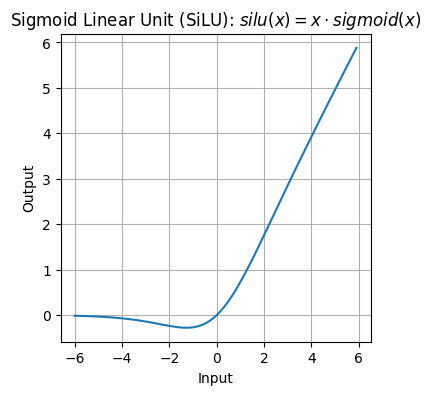

In [20]:
m = nn.SiLU()                                                               # instancia a função de ativação SiLU (Sigmoid Linear Unit)
input = torch.arange(-6, 6, 0.1)                                            # cria tensor 1D de entradas no intervalo [-6, 6)
output = m(input)                                                           # aplica a ativação SiLU: x * sigmoid(x)
plt.figure(figsize=(4,4))                                                   # cria figura 4×4 polegadas
plt.plot(input, output)                                                     # plota curva de ativação
plt.title(r"Sigmoid Linear Unit (SiLU): $silu(x) = x \cdot sigmoid(x)$")    # título com fórmula em LaTeX
plt.xlabel("Input")                                                         # rótulo do eixo x
plt.ylabel("Output")                                                        # rótulo do eixo y
plt.grid()                                                                  # adiciona grade ao gráfico
plt.show()                                                                  # exibe o gráfico

## Visualizar rede neural

In [21]:
network = NeuralNet(time_encoder=time_enc).to(DEVICE)   # instancia a rede e move para o device (CPU/GPU)

In [22]:
# gera o resumo da arquitetura com torchinfo
summary(
    network,
    input_size=[(1, 2), (1,)],                                                                                          # shapes de entrada: x_t (B,2) e t (B,)
    dtypes=[torch.float32, torch.int64],                                                                                # tipos das entradas: x_t float32, t int64 (índices)
    col_names=("input_size", "output_size", "num_params", "params_percent", "kernel_size", "mult_adds", "trainable"),   # colunas exibidas no relatório
    depth=3                                                                                                             # profundidade de expansão do módulo (nível de detalhamento)
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
NeuralNet                                [1, 2]                    [1, 2]                    --                             --                   --                        --                        True
├─TimeEncoding: 1-1                      [1]                       [1, 32]                   --                             --                   --                        --                        --
├─Sequential: 1-2                        [1, 32]                   [1, 32]                   --                             --                   --                        --                        True
│    └─Linear: 2-1                       [1, 32]                   [1, 32]                   1,056                      19.52%                   --                        1,056             

# Classe do Modelo de difusão

In [23]:
class DiffusionModel(nn.Module):
    """
    Wrapper de alto nível para DDPM.

    Esta classe encapsula:
      (i)  o cronograma de ruído (betas, alphas, alphas_bar);
      (ii) a rede que prediz o ruído ε̂(x_t, t);
      (iii) as rotinas de amostragem direta e reversa.

    Parameters
    ----------
    network : nn.Module
        Rede que recebe (x_t, t) e prediz o ruído ε̂  do mesmo shape de x_t.
    noise_scheduler : NoiseScheduler
        Objeto com buffers/atributos {betas, alphas, alphas_bar, T} (passos de difusão).

    Attributes
    ----------
    network : nn.Module
        Modelo que implementa ε̂_θ(x_t, t).
    noise_scheduler : NoiseScheduler
        Fornece vetores 1-D de parâmetros por passo t: betas, alphas e alphas_bar.

    Notes
    -----
    - `forward_diffusion` implementa a amostragem direta z_t ~ q(z_t|x_0).
    - `reverse_diffusion_step` implementa um passo reverso x_{t-1} a partir de x_t (DDPM).
    - `reverse_diffusion_step_loop` executa toda a cadeia reversa de T→0.
    """

    def __init__(self, network: nn.Module, noise_scheduler: "NoiseScheduler") -> None:
        """Inicializa com rede preditora de ruído e agendador de variâncias."""
        super().__init__()                         # inicializa superclasse
        self.network: nn.Module = network          # salva a rede ε̂_θ
        self.noise_scheduler: "NoiseScheduler" = noise_scheduler  # salva o agendador

    @torch.no_grad()
    def forward_diffusion(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Amostra z_t ~ q(z_t | x_0) = N( sqrt(α̅_t)·x_0, (1-α̅_t)·I ).

        Parameters
        ----------
        x : torch.Tensor
            Dados limpas x_0 no formato (B, 2) a serem mapeados ao passo t,
            onde B é o tamanho do batch e cada amostra contém duas coordenadas (x, y).
        t : torch.Tensor
            Passos inteiros no intervalo [0, T], shape (B,).

        Returns
        -------
        zt : torch.Tensor
            Amostras z_t com o mesmo shape de x.
        """

        noise = torch.randn_like(x)                                     # ruído ε ~ N(0, I)
        B = x.shape[0]                                                  # tamanho do batch
        alpha_bar = self.noise_scheduler.alphas_bar[t].view(B, 1)       # α̅_t com broadcast
        zt = alpha_bar.sqrt() * x + (1.0 - alpha_bar).sqrt() * noise    # z_t = √α̅_t x_0 + √(1-α̅_t) ε
        return zt

    @torch.no_grad()
    def reverse_diffusion_step(self, xt: torch.Tensor, t: Union[torch.Tensor, int]) -> torch.Tensor:
        """
        Executa um único passo de difusão reversa (denoising) no processo DDPM para dados 2D.

        Em cada passo t, o modelo prediz o ruído ε̂(x_t, t) e estima a amostra
        menos ruidosa x_{t-1} a partir de x_t, de acordo com a fórmula:

            x_{t-1} = 1/√α_t · ( x_t - (β_t / √(1-α̅_t)) · ε̂_θ(x_t, t) ) + √β_t · z

        onde z ~ N(0, I) se t > 1; caso t = 1, z = 0.

        Parameters
        ----------
        xt : torch.Tensor
            Amostras ruidosas no passo t, shape (B, 2), com B pontos 2D.
        t : torch.Tensor or int
            Passo de difusão atual (escalar ou tensor de inteiros) em contagem regressiva.

        Returns
        -------
        x_prev : torch.Tensor
            Amostras x_{t-1} menos ruidosas, com o mesmo shape de xt, isto é (B, 2).
        """

        B = xt.shape[0]                                                         # tamanho do batch
        t_int = int(t) if not torch.is_tensor(t) else int(t.item())             # garante escalar int para indexação
        t_batch = torch.full((B,), t_int, device=DEVICE, dtype=torch.long)      # vetor de tempos (B,)
        noise = torch.randn_like(xt) if t_int > 1 else torch.zeros_like(xt)     # z ~ N(0,I) (ou 0 no último passo)
        epsilon_pred = self.network(xt, t_batch)                                # prediz ruído ε̂^(x_t, t)
        # aplica a equação de remoção do ruído (denoising): x_t → x_{t-1
        x_prev = (
            1 / self.noise_scheduler.alphas[t].sqrt()
            * (xt - self.noise_scheduler.betas[t] / (1 - self.noise_scheduler.alphas_bar[t]).sqrt() * epsilon_pred)
            + self.noise_scheduler.betas[t].sqrt() * noise
        )
        return x_prev

    @torch.no_grad()
    def reverse_diffusion_step_loop(self, batch_size: int = 1024) -> torch.Tensor:
        """
        Processo reverso de difusão completo para dados 2D:

        Inicia com amostras z_T ~ N(0, I) e aplica o processo de difusão reversa
        (T → 0) para obter as amostras finais x (x_T -> x_0).

        Parameters
        ----------
        batch_size : int, default=1024
            Número de amostras 2D a gerar (cada uma com duas coordenadas).

        Returns
        -------
        torch.Tensor
            Amostras finais x após T passos de denoising.
        """

        x_pred = torch.randn((batch_size, 2), device=DEVICE)                    # z_T ~ N(0, I)
        for t in tqdm(range(self.noise_scheduler.T, 0, -1), desc="Amostragem (processo reverso)", unit="passo"):
            x_pred = self.reverse_diffusion_step(x_pred, t)                     # aplica DDPM: z_t → z_{t-1}
        return x_pred

    @torch.no_grad()
    def prepare_batch_2d(self, Xb: torch.Tensor) -> Tuple[Dict[str, torch.Tensor], torch.Tensor]:
        """
        Prepara um batch 2D para treinamento do DDPM (predição de ε̂  a partir de x_t e t).

        Para cada amostra x_0 (ponto 2D) seleciona-se um passo t ~ Uniform{1,...,T},
        amostra-se ruído ε ~ N(0, I) e constrói-se a versão ruidosa:
            x_t = √α̅_t · x_0 + √(1−α̅_t) · ε,
        onde α̅_t vem do cronograma de ruído.

        Parameters
        ----------
        Xb : torch.Tensor
            Batch de pontos 2D limpos x_0, shape (B, 2), dtype float32.

        Returns
        -------
        inputs : Dict[str, torch.Tensor]
            Dicionário com:
                - "X_noisy": x_t ruidoso (B, 2)
                - "time": passos inteiros t em [1, T] (B,)
        target : torch.Tensor
            Ruído gaussiano ε usado para gerar x_t, shape (B, 2).
        """

        Xb = Xb.to(DEVICE)                                                  # garante que o batch está no device correto
        B = Xb.shape[0]                                                     # tamanho do batch (número de amostras)
        T_max = int(self.noise_scheduler.T)                                 # total de passos T (do cronograma)
        t = torch.randint(low=1, high=T_max + 1, size=(B,), device=DEVICE)  # amostra t ~ Uniform{1,...,T}
        alpha_bar = self.noise_scheduler.alphas_bar[t].view(B, 1)           # obtém α̅_t e ajusta para broadcast (B,1)
        noise = torch.randn_like(Xb, device=DEVICE)                         # amostra ε ~ N(0,I) com shape (B,2)
        X_noisy = alpha_bar.sqrt() * Xb + (1.0 - alpha_bar).sqrt() * noise  # x_t = √α̅_t·x_0 + √(1−α̅_t)·ε
        inputs = {"X_noisy": X_noisy, "time": t}                            # empacota entradas para a rede (x_t, t)
        target = noise                                                      # alvo supervisionado é o próprio ruído ε

        return inputs, target

# Instância do modelo de difusão

In [136]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # usa GPU se disponível, caso contrário CPU
BATCH_SIZE = 256                                                       # tamanho do batch para treino
MODE = "cosine"                                                        # modo do scheduler de ruído ("linear", "quad", "cosine", etc.)
DATASET = "swiss_roll"                                                       # tipo de dataset 2D (ex.: "circle", "scurve", "moon", "swiss_roll")
NUM_EPOCHS = 50                                                        # número total de épocas de treinamento
BATCH_SIZE_SAMPLING = 1024                                             # tamanho do batch usado na amostragem (geração)
EMBEDDING_SIZE = 2                                                   # tamanho do embedding temporal (número de dimensões do encoding senoidal)
NUM_STEPS = 500  

noise_scheduler = NoiseScheduler(T=NUM_STEPS, mode=MODE).to(DEVICE)                 # Cronograma de Ruído
time_enc        = TimeEncoding(T=NUM_STEPS, embed_size=EMBEDDING_SIZE).to(DEVICE)   # Embeddings temporais
network         = NeuralNet(time_encoder=time_enc, t_hidden=128).to(DEVICE)         # Rede Neural
model           = DiffusionModel(network, noise_scheduler)                          # Modelo de difusão completo

# Visualizar processo de difusão direto

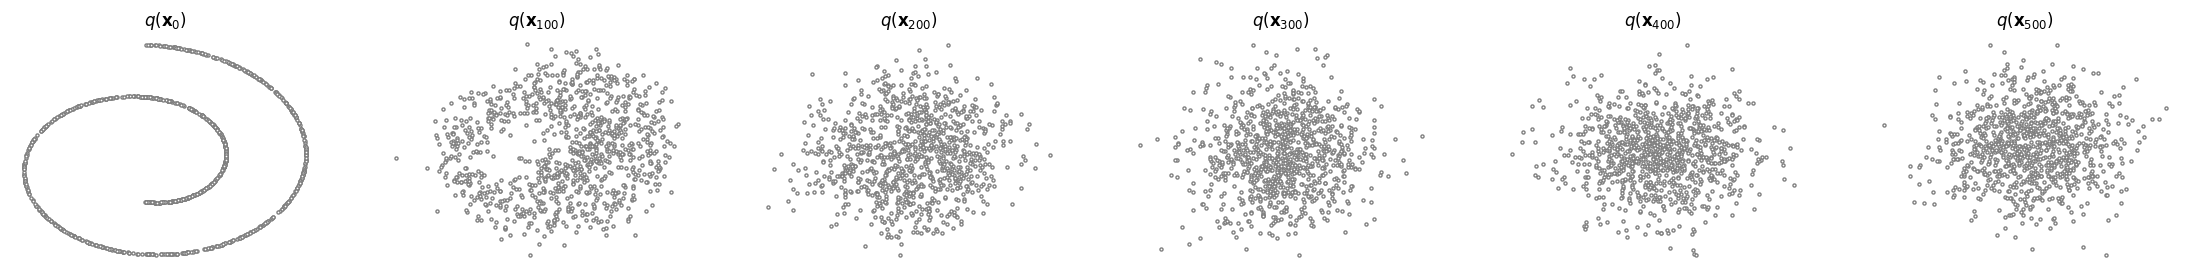

In [147]:
fig, axs = plt.subplots(1, 6, figsize=(28, 3))                                 # cria figura com 11 subplots (1 linha × 11 colunas)
for i, time in enumerate(range(0, NUM_STEPS+NUM_STEPS//5, NUM_STEPS//5)):                                  # itera tempos de 0 até 1000 em passos de 100
    x = train_ds[:num_samples_plot][0].to(DEVICE)                              # seleciona um subconjunto de partículas limpas x_0
    t = (torch.ones(num_samples_plot) * time).long().to(DEVICE)                # cria vetor de tempos t (todos com mesmo valor 'time')
    x_t = model.forward_diffusion(x, t).cpu()                                   # aplica processo direto (adiciona ruído) e move para CPU
    axs[i].scatter(x_t[:,0], x_t[:,1], color='white', edgecolor='gray', s=5)    # plota amostras 2D ruidosas em cada subplot
    axs[i].set_axis_off()                                                       # remove eixos para visualização mais limpa
    axs[i].set_title(fr"$q(\mathbf{{x}}_{{{time}}})$")                          # título indicando a distribuição q(x_t): (t=0: dados originais)

# Treinamento

In [120]:
criterion = nn.MSELoss()                                       # define a função de perda MSE (erro quadrático médio)
optimizer = optim.Adam(model.network.parameters(), lr=1e-3)    # usa o otimizador Adam com taxa de aprendizado 1e-3

In [121]:
def train_one_epoch(model, dataloader, criterion, optimizer):
    model.train()                                               # coloca o modelo em modo de treino
    total_loss = 0.0                                            # inicializa acumulador de perda
    for (xb, ) in dataloader:                                   # itera batches do DataLoader (cada xb é um batch 2D)
        xb = xb.to(DEVICE)                                      # move o batch para o device (CPU/GPU)
        (inputs, noise) = model.prepare_batch_2d(xb)            # gera x_t ruidoso e o ruído ε correspondente
        x_noisy = inputs["X_noisy"]                             # extrai amostras ruidosas x_t
        t = inputs["time"]                                      # extrai tempos de difusão t para cada amostra

        # Forward
        eps_hat = model.network(x_noisy, t)                     # rede prediz ruído ε̂  a partir de (x_t, t)
        loss = criterion(eps_hat, noise)                        # calcula erro quadrático entre ε̂  e ε

        # Backprop
        optimizer.zero_grad()                                   # zera gradientes acumulados
        loss.backward()                                         # retropropaga o erro
        optimizer.step()                                        # atualiza pesos da rede

        total_loss += loss.item() * xb.shape[0]                 # acumula perda total (ponderada pelo tamanho do batch)
    return total_loss / len(dataloader.dataset)                 # retorna perda média por amostra no epoch

In [122]:
loss_history = []  # lista para armazenar histórico de perdas
with tqdm(range(1, NUM_EPOCHS + 1), desc="Treinando épocas", unit="época") as pbar:   # barra de progresso para monitorar as épocas
    for epoch in pbar:                                                                # itera sobre cada época
        train_loss = train_one_epoch(model, train_dl, criterion, optimizer)           # executa uma época de treinamento
        loss_history.append(train_loss)                                                # armazena a perda da época atual
        pbar.set_postfix_str(f"função de perda: {train_loss:.6f}")                    # exibe a perda atual na barra de progresso

Treinando épocas:   0%|          | 0/50 [00:00<?, ?época/s]

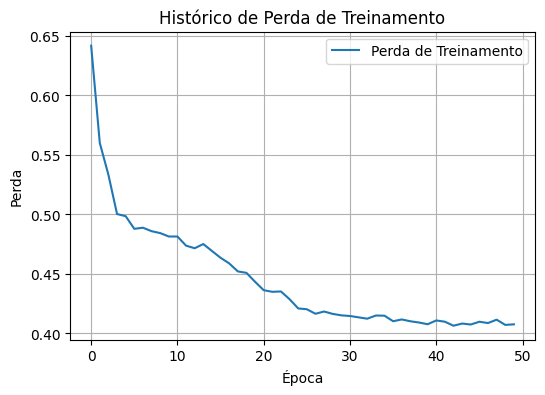

In [123]:
# Gráfico de histórico da perda de treinamento
plt.figure(figsize=(6,4))                                      # cria figura 6x4 polegadas
plt.plot(loss_history, label="Perda de Treinamento")          # plota histórico de perdas
plt.xlabel("Época")                                            # rótulo do eixo x
plt.ylabel("Perda")                                           # rótulo do eixo y
plt.title("Histórico de Perda de Treinamento")               # título do gráfico
plt.legend()                                                  # exibe legenda
plt.grid()                                                   # exibe grade
plt.show()                                                   # exibe gráfico

# Geração

Amostragem (processo reverso):   0%|          | 0/1000 [00:00<?, ?passo/s]

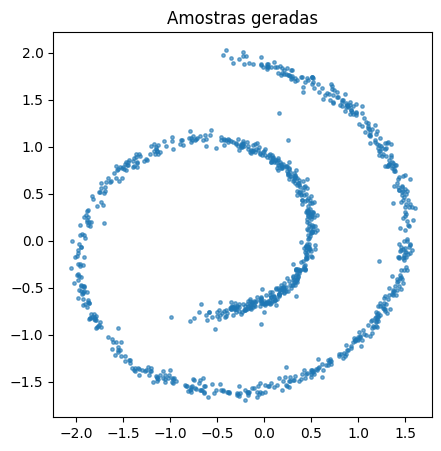

In [124]:
torch.manual_seed(42)                                                        # fixa a semente aleatória para reprodutibilidade

# Amostragem a partir do processo reverso de difusão:
X_gen = model.reverse_diffusion_step_loop(batch_size=BATCH_SIZE_SAMPLING)    # gera novas amostras x_0 a partir de ruído puro (x_T ~ N(0,I))

# Visualização das amostras geradas
plt.figure(figsize=(5,5))                                                    # cria figura quadrada 5x5
plt.scatter(X_gen[:,0].cpu(), X_gen[:,1].cpu(), s=6, alpha=0.6)              # plota amostras 2D (x, y) no plano
plt.gca().set_aspect("equal", adjustable="box")                              # mantém proporção 1:1 nos eixos
plt.title("Amostras geradas")                                                # título do gráfico
plt.show()                                                                   # exibe o gráfico

# Visualizar processo de difusão reverso

In [125]:
num_samples_plot = 1000                                      # número de partículas (amostras) a visualizar
T = NUM_STEPS                                                # número total de passos de difusão
checkpoint_stride = NUM_STEPS//5                                      # intervalo entre snapshots (salvar a cada 100 steps)
times_to_show = list(range(T, -1, -checkpoint_stride))       # define tempos que serão exibidos: T, T-100, ..., 0
if times_to_show[-1] != 0:
    times_to_show.append(0)                                  # garante que t=0 sempre apareça
with torch.no_grad():                                        # desativa gradientes (modo inferência)
    model.network.eval()                                     # coloca rede em modo avaliação
    x = torch.randn(num_samples_plot, 2, device=DEVICE)      # inicializa x_T ~ N(0, I)
    snaps = {T: x.detach().cpu()}                            # dicionário para armazenar snapshots (tempo -> pontos)
    for t in range(T, 0, -1):                                # loop reverso: t = T, T-1, ..., 1
        x = model.reverse_diffusion_step(x, t)               # aplica um passo de difusão reversa: x_t -> x_{t-1}
        if (t-1) in times_to_show:                           # salva snapshot se o tempo for de interesse
            snaps[t-1] = x.detach().cpu()                    # armazena cópia em CPU (sem gradiente)

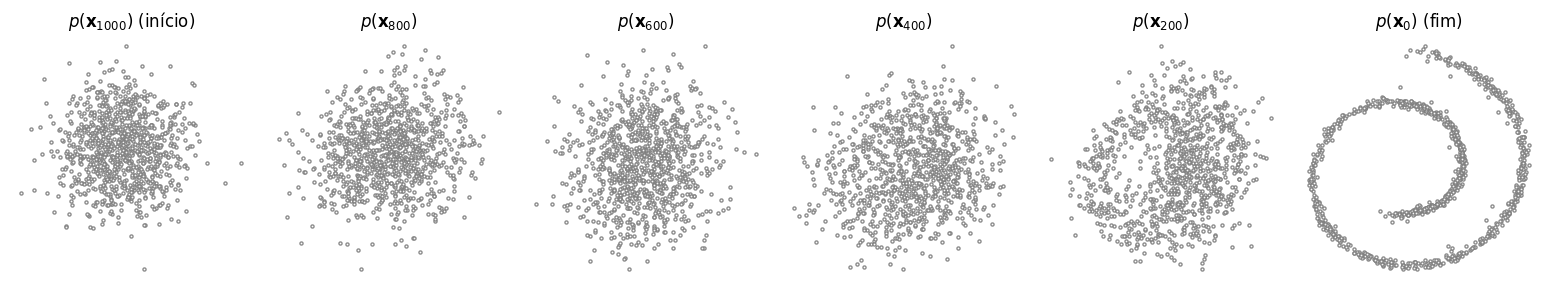

In [126]:
# Figuras dos snapshots
cols = len(times_to_show)                                    # número de colunas (um subplot por tempo salvo)
fig, axs = plt.subplots(1, cols, figsize=(2.6*cols, 3))      # cria figura horizontal
for i, time in enumerate(times_to_show):
    xt = snaps[time]                                         # recupera amostras no tempo t
    axs[i].scatter(xt[:, 0], xt[:, 1],                       # plota pontos 2D
                   color='white', edgecolor='gray', s=5, alpha=0.9)
    axs[i].set_axis_off()                                    # remove eixos
    if i == 0:                                               # primeiro subplot (início da difusão reversa)
        axs[i].set_title(fr"$p(\mathbf{{x}}_{{{time}}})$" + " (início)")
    elif time == 0:                                          # último subplot (amostras finais x_0)
        axs[i].set_title(fr"$p(\mathbf{{x}}_0)$" + " (fim)")
    else:                                                    # demais tempos intermediários
        axs[i].set_title(fr"$p(\mathbf{{x}}_{{{time}}})$")
plt.tight_layout()                                           # ajusta espaçamento entre subplots
plt.show()                                                   # exibe figura

# Tarefa

- Escolha um outro conjunto de dados (ex.: "circle", "scurve", "swiss_roll").

- Realize experimentos com 3  valores diferentes de NUM_STEPS e EMBEDDING_SIZE.

- Mostre as figuras com os processos direto e reverso de difusão.

**Entregáveis**:
1. Notebook `.ipynb`.
2. Relatório `.pdf`:
    - Reporte e comente os resultados no relatório.
    - Incluir gráficos gerados.